Gradient Boosting Accuracy: 0.9685185185185186
Stacking Accuracy: 0.9629629629629629
Best Parameters: {'n_estimators': 200, 'max_depth': None}
Best Score: 0.9689875418959083
Accuracy with Bootstrap: 0.9777777777777777
Accuracy without Bootstrap: 0.975925925925926


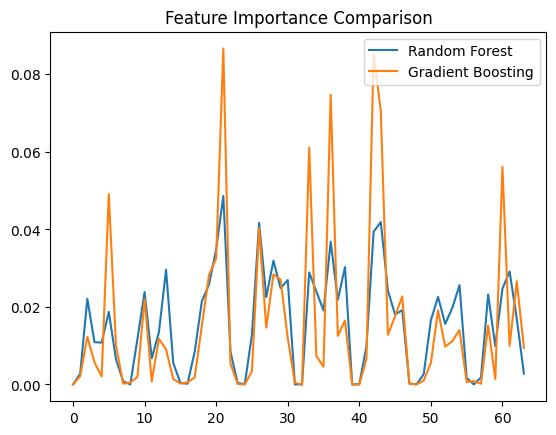

In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ------------------------------
# Load Dataset
# ------------------------------

digits = load_digits()

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ==================================================
# Gradient Boosting Classifier
# ==================================================

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))


# ==================================================
# Stacking Ensemble
# ==================================================

base_models = [
    ('rf', RandomForestClassifier(n_estimators=50)),
    ('dt', DecisionTreeClassifier(max_depth=5))
]

stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)

stack_pred = stack.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, stack_pred))


# ==================================================
# Hyperparameter Tuning – RandomizedSearchCV
# ==================================================

param_dist = {
    'n_estimators': [50,100,150,200],
    'max_depth': [5,10,15,None]
}

rf = RandomForestClassifier()

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=5
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)


# ==================================================
# Bootstrap Sampling Effect
# ==================================================

rf_bootstrap = RandomForestClassifier(bootstrap=True)
rf_no_bootstrap = RandomForestClassifier(bootstrap=False)

rf_bootstrap.fit(X_train, y_train)
rf_no_bootstrap.fit(X_train, y_train)

pred1 = rf_bootstrap.predict(X_test)
pred2 = rf_no_bootstrap.predict(X_test)

print("Accuracy with Bootstrap:", accuracy_score(y_test, pred1))
print("Accuracy without Bootstrap:", accuracy_score(y_test, pred2))


# ==================================================
# Feature Importance Comparison
# ==================================================

import matplotlib.pyplot as plt

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

plt.plot(rf.feature_importances_, label="Random Forest")
plt.plot(gb.feature_importances_, label="Gradient Boosting")

plt.legend()
plt.title("Feature Importance Comparison")
plt.show()